# AutoGluon Cross‑Validation vs. Holdout on **Palmer Penguins** (Body Mass Regression)

**Goal:** Show why cross‑validation (CV) with AutoGluon often outperforms a simple train/test holdout for tabular **regression**.

**Dataset:** Palmer Penguins — predict the numeric target **`body_mass_g`** from numeric and categorical features.

**What you'll learn**
- How to load the Penguins dataset.
- How to run **holdout** training in AutoGluon (no CV).
- How to run **CV + stacking/bagging** in AutoGluon and inspect the leaderboard.
- How to compare regression metrics (RMSE, MAE, R²) on an **unseen test set**.
- Quick residual diagnostics (Predicted vs Actual, Residuals).

> **Instructor note**: Set `TIME_LIMIT_SEC` lower (e.g., 60) for quick demos or higher (e.g., 300) for better accuracy.


## 1) Setup
If your environment already has the required libraries, you can skip the `pip` cell.


In [1]:
#!pip -q install seaborn palmerpenguins
#!pip -q install autogluon.tabular


In [2]:
import os, sys, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil  # cross-platform directory cleanup

from autogluon.tabular import TabularPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TIME_LIMIT_SEC = 120  # adjust for class time
TEST_SIZE = 0.2


C:\Users\biauser\anaconda3\envs\ag312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\biauser\anaconda3\envs\ag312\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 2) Load the Penguins dataset
We include basic fallbacks so this works reliably across machines.


In [3]:
def load_penguins_with_fallbacks():
    # 1) Try seaborn bundled
    try:
        df = sns.load_dataset('penguins')
        if df is not None and len(df) > 0:
            return df
    except Exception as e:
        pass
    # 2) Try palmerpenguins package
    try:
        from palmerpenguins import load_penguins
        df = load_penguins()
        if df is not None and len(df) > 0:
            return df
    except Exception:
        pass
    # 3) Try direct CSV (requires internet)
    try:
        url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv'
        df = pd.read_csv(url)
        return df
    except Exception as e:
        raise RuntimeError('Failed to load Penguins dataset via all fallbacks.')

penguins = load_penguins_with_fallbacks()
print(penguins.shape)
penguins.head()


(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 3) Quick EDA and target selection
We will predict the numeric target **`body_mass_g`** (penguin body mass in grams). AutoGluon handles missing values and encoding automatically, so we keep preprocessing minimal.


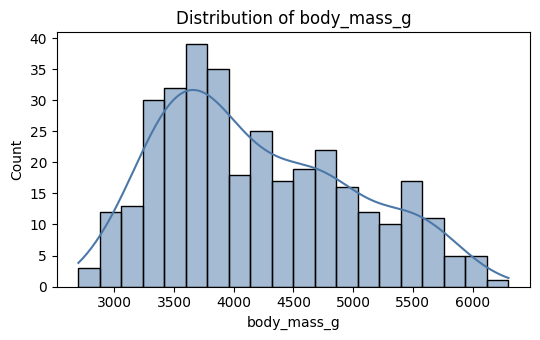

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [4]:
label = 'body_mass_g'

# Basic cleaning: drop rows where the label is missing
penguins = penguins.dropna(subset=[label]).copy()

# Quick distribution plot for the target
plt.figure(figsize=(5.5,3.5))
sns.histplot(penguins[label], bins=20, kde=True, color='#4c78a8')
plt.title('Distribution of body_mass_g')
plt.xlabel('body_mass_g')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Peek at columns
penguins.info()


In [5]:
#penguins[penguins['body_mass_g'].isna()]

### Features and label
We'll include both numeric and categorical columns. AutoGluon can infer types directly from the DataFrame.


In [6]:
feature_cols = [c for c in penguins.columns if c != label]
penguins[feature_cols + [label]].head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,Male,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,Female,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,Female,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,Female,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,Male,3650.0


## 4) Create a **manual holdout** split (no scikit‑learn dependency)
We’ll randomly sample 20% for the test set using NumPy/pandas. This **test set** is kept untouched during training for final evaluation.


In [7]:

n = len(penguins)
perm = np.random.permutation(n)
cut = int(n * (1 - TEST_SIZE))
train_idx, test_idx = perm[:cut], perm[cut:]

train_df = penguins.iloc[train_idx].reset_index(drop=True)
test_df  = penguins.iloc[test_idx].reset_index(drop=True)

train_df.shape, test_df.shape


((273, 7), (69, 7))

In [8]:
train_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Gentoo,Biscoe,46.2,14.5,209.0,4800.0,Female
1,Adelie,Torgersen,37.3,20.5,199.0,3775.0,Male
2,Adelie,Biscoe,39.6,20.7,191.0,3900.0,Female
3,Adelie,Dream,44.1,19.7,196.0,4400.0,Male
4,Adelie,Torgersen,41.5,18.3,195.0,4300.0,Male
...,...,...,...,...,...,...,...
268,Chinstrap,Dream,45.2,17.8,198.0,3950.0,Female
269,Adelie,Dream,40.8,18.4,195.0,3900.0,Male
270,Gentoo,Biscoe,55.9,17.0,228.0,5600.0,Male
271,Gentoo,Biscoe,50.4,15.3,224.0,5550.0,Male


## 5) AutoGluon with **Holdout** (no CV / no bagging)
We fit on the training set with default settings (no stacking/bagging). AutoGluon will internally keep a small validation holdout for model selection. Then we evaluate on our **unseen** test set.


In [9]:
SAVE_PATH_HOLDOUT = Path('agModels-reg-holdout')

# Safe, cross-platform cleanup
if SAVE_PATH_HOLDOUT.exists() and SAVE_PATH_HOLDOUT.is_dir():
    shutil.rmtree(SAVE_PATH_HOLDOUT)

predictor_holdout = TabularPredictor(
    label=label,
    path=str(SAVE_PATH_HOLDOUT),
    problem_type='regression',
    eval_metric='r2'  # prioritize R^2 during model selection
).fit(
    train_data=train_df,
    time_limit=TIME_LIMIT_SEC,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.87 GB / 15.99 GB (43.0%)
Disk Space Avail:   19.81 GB / 127.45 GB (15.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`

In [10]:
print('Holdout → Test evaluation:')
holdout_test_metrics = predictor_holdout.evaluate(test_df)

print('Holdout Leaderboard on Test:')
holdout_lb_test = predictor_holdout.leaderboard(test_df, silent=True)
holdout_lb_test.head()

Holdout → Test evaluation:
Holdout Leaderboard on Test:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesMSE,0.837562,0.857112,r2,0.099669,0.054199,0.604056,0.099669,0.054199,0.604056,1,True,5
1,NeuralNetTorch,0.832802,0.884872,r2,0.014048,0.008514,2.827023,0.014048,0.008514,2.827023,1,True,8
2,LightGBMXT,0.832754,0.866011,r2,0.035610,0.006516,2.038233,0.035610,0.006516,2.038233,1,True,1
3,WeightedEnsemble_L2,0.831856,0.886807,r2,0.035120,0.018028,3.384792,0.003525,0.001507,0.073692,2,True,10
4,CatBoost,0.829802,0.856349,r2,0.017041,0.004000,8.166707,0.017041,0.004000,8.166707,1,True,4


## 6) AutoGluon with **Cross‑Validation + Stacking/Bagging**
Enable CV by turning on bagging/stacking. We’ll use **5 folds** and **1 stack level**. AutoGluon trains models on folds, blends them, and often gains stability and accuracy.


In [11]:
SAVE_PATH_CV = Path('agModels-reg-cv')

# Clean up old directory if it exists
if SAVE_PATH_CV.exists() and SAVE_PATH_CV.is_dir():
    shutil.rmtree(SAVE_PATH_CV)

predictor_cv = TabularPredictor(
    label=label,
    path=str(SAVE_PATH_CV),
    problem_type='regression',
    eval_metric='r2'
).fit(
    train_data=train_df,
    time_limit=TIME_LIMIT_SEC,
    auto_stack=True,        # enables bagging + stacking
    num_bag_folds=5,
    num_stack_levels=1,
)



Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.72 GB / 15.99 GB (42.0%)
Disk Space Avail:   19.80 GB / 127.45 GB (15.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`

In [12]:
print('CV → Test evaluation:')
cv_test_metrics = predictor_cv.evaluate(test_df)

print('CV Leaderboard on Test:')
cv_lb_test = predictor_cv.leaderboard(test_df, silent=True)
cv_lb_test.head()

CV → Test evaluation:
CV Leaderboard on Test:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestMSE_BAG_L1,0.842463,0.857723,r2,0.156459,0.114836,0.643185,0.156459,0.114836,0.643185,1,True,3
1,RandomForestMSE_BAG_L2,0.842416,0.866416,r2,0.820696,0.634818,46.265553,0.143420,0.184107,0.886196,2,True,12
2,ExtraTreesMSE_BAG_L1,0.842374,0.865325,r2,0.133190,0.108147,0.598119,0.133190,0.108147,0.598119,1,True,5
3,CatBoost_BAG_L1,0.840308,0.873950,r2,0.105778,0.021052,16.744340,0.105778,0.021052,16.744340,1,True,4
4,WeightedEnsemble_L2,0.839921,0.887963,r2,0.285357,0.208183,27.491168,0.003509,0.001508,0.097455,2,True,9


## 7) Compare results (unseen test set)
We line up key regression metrics from both approaches. (Exact numbers vary with randomness and time budget.)


In [13]:
def extract_metric(metrics_dict, key_candidates):
    for k in key_candidates:
        if k in metrics_dict:
            return metrics_dict[k]
    return np.nan

rows = []
rows.append({
    'approach': 'Holdout (no CV)',
    'rmse': extract_metric(holdout_test_metrics, ['root_mean_squared_error', 'rmse']),
    'mae':  extract_metric(holdout_test_metrics, ['mean_absolute_error', 'mae']),
    'r2':   extract_metric(holdout_test_metrics, ['r2', 'r2_score']),
})
rows.append({
    'approach': 'CV + stacking (5 folds)',
    'rmse': extract_metric(cv_test_metrics, ['root_mean_squared_error', 'rmse']),
    'mae':  extract_metric(cv_test_metrics, ['mean_absolute_error', 'mae']),
    'r2':   extract_metric(cv_test_metrics, ['r2', 'r2_score']),
})

cmp_df = pd.DataFrame(rows)
cmp_df


,approach,rmse,mae,r2
0,Holdout (no CV),-332.873318,-264.649287,0.831856
1,CV + stacking (5 folds),-324.792064,-263.167760,0.839921


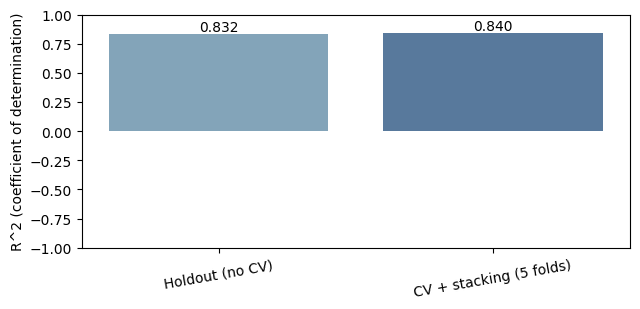

In [14]:
# Simple bar chart for R^2
plt.figure(figsize=(6.5,3.2))
ax = sns.barplot(data=cmp_df, x='approach', y='r2', hue='approach', palette=['#7aa6c2', '#4c78a8'], legend=False)
ax.set_ylim(-1, 1)
ax.set_xlabel('')
ax.set_ylabel('R^2 (coefficient of determination)')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}', (p.get_x()+p.get_width()/2, height), ha='center', va='bottom')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### Residual diagnostics
For regression, it’s helpful to examine predictions vs actuals and residual distributions.


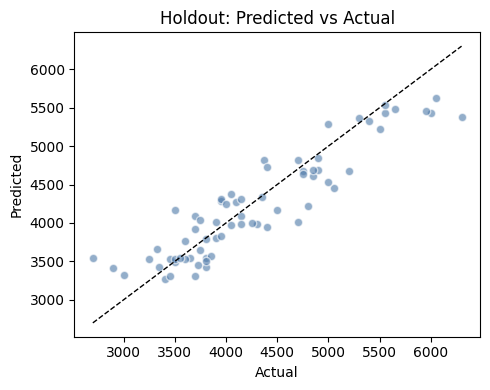

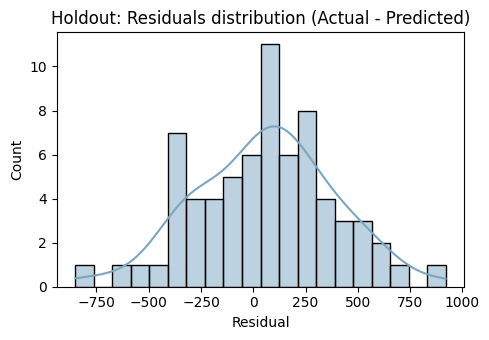

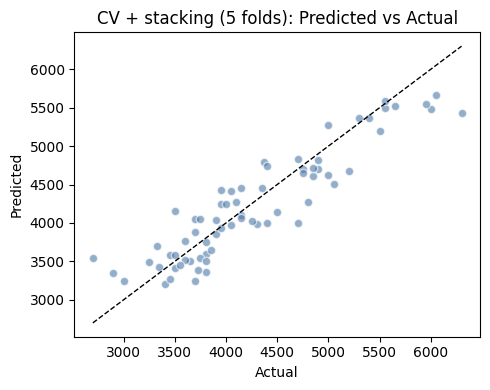

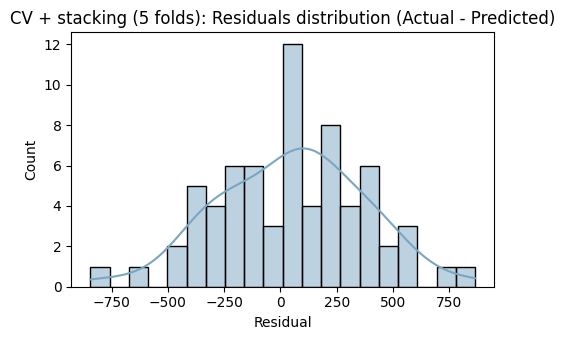

In [15]:
def residual_plots(predictor, test_df, title_prefix='Model'):
    y_true = test_df[label].values
    y_pred = predictor.predict(test_df).values
    residuals = y_true - y_pred
    
    # Predicted vs Actual
    plt.figure(figsize=(5,4))
    plt.scatter(y_true, y_pred, alpha=0.6, color='#4c78a8', edgecolor='white')
    minv, maxv = np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])
    plt.plot([minv, maxv], [minv, maxv], 'k--', lw=1)
    plt.title(f'{title_prefix}: Predicted vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    # Residuals histogram
    plt.figure(figsize=(5,3.5))
    sns.histplot(residuals, bins=20, kde=True, color='#7aa6c2')
    plt.title(f'{title_prefix}: Residuals distribution (Actual - Predicted)')
    plt.xlabel('Residual')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

residual_plots(predictor_holdout, test_df, title_prefix='Holdout')
residual_plots(predictor_cv, test_df, title_prefix='CV + stacking (5 folds)')


## 8) Takeaways and next steps
- For tabular regression, **CV + stacking/bagging** in AutoGluon is a strong default for stability and accuracy.
- Keep a **separate, untouched test set** for final grading.
- Increase `TIME_LIMIT_SEC` or use `presets='best_quality'` for higher accuracy in longer labs.
- Explore `predictor_cv.leaderboard(test_df)` to see which base learners drive performance.

**Optional exercises**
1. Change `num_bag_folds` to 3 or 10 and observe R²/RMSE changes.
2. Try `num_stack_levels=2` for deeper stacking.
3. Set `eval_metric='root_mean_squared_error'` and compare ranks vs `r2`.
